<h1>Data Scraping and Preprocessing using Python and Scrapy</h1>

<h2>Name: Puranik Aryan Hitesh
    <br>
    Student Id: 202618030
    <br>
    Lab 01 Assignment
</h2>

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("books.csv")

Total No. of records Scraped: 200
Total No. of missing vaules: 1 (description)
Total no. of Duplicate UPC{Universal Product Code} : 0

In [3]:
df.head()

,title,price,rating,availability,category,upc,price_excl_tax,price_incl_tax,tax,number_of_reviews,description,url
0,It's Only the Himalayas,£45.17,Two,In stock (19 available)\n \n\n \n \n ...,Travel,a22124811bfa8350,£45.17,£45.17,£0.00,0,"“Wherever you go, whatever you do, just . . . ...",https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,£51.33,Two,In stock (19 available)\n \n\n \n \n ...,Politics,a18a4f574854aced,£51.33,£51.33,£0.00,0,Libertarianism isn't about winning elections; ...,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,£37.59,One,In stock (19 available)\n \n\n \n \n ...,Science Fiction,e30f54cea9b38190,£37.59,£37.59,£0.00,0,"Andrew Barger, award-winning author and engine...",https://books.toscrape.com/catalogue/mesaerion...
3,Olio,£23.88,One,In stock (19 available)\n \n\n \n \n ...,Poetry,feb7cc7701ecf901,£23.88,£23.88,£0.00,0,"Part fact, part fiction, Tyehimba Jess's much ...",https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,£57.25,Three,In stock (19 available)\n \n\n \n \n ...,Music,deda3e61b9514b83,£57.25,£57.25,£0.00,0,This is the never-before-told story of the mus...,https://books.toscrape.com/catalogue/our-band-...


In [4]:
df.describe()

,number_of_reviews
count,200.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [5]:
df.tail()

,title,price,rating,availability,category,upc,price_excl_tax,price_incl_tax,tax,number_of_reviews,description,url
195,Sapiens: A Brief History of Humankind,£54.23,Five,In stock (20 available)\n \n\n \n \n ...,History,4165285e1663650f,£54.23,£54.23,£0.00,0,From a renowned historian comes a groundbreaki...,https://books.toscrape.com/catalogue/sapiens-a...
196,Sharp Objects,£47.82,Four,In stock (20 available)\n \n\n \n \n ...,Mystery,e00eb4fd7b871a48,£47.82,£47.82,£0.00,0,"WICKED above her hipbone, GIRL across her hear...",https://books.toscrape.com/catalogue/sharp-obj...
197,Soumission,£50.10,One,In stock (20 available)\n \n\n \n \n ...,Fiction,6957f44c3847a760,£50.10,£50.10,£0.00,0,"Dans une France assez proche de la nôtre, un h...",https://books.toscrape.com/catalogue/soumissio...
198,Tipping the Velvet,£53.74,One,In stock (20 available)\n \n\n \n \n ...,Historical Fiction,90fa61229261140a,£53.74,£53.74,£0.00,0,"""Erotic and absorbing...Written with starling ...",https://books.toscrape.com/catalogue/tipping-t...
199,A Light in the Attic,£51.77,Three,In stock (22 available),Poetry,a897fe39b1053632,£51.77,£51.77,£0.00,0,It's hard to imagine a world without A Light i...,https://books.toscrape.com/catalogue/a-light-i...


<h2>Data Preprocessing</h2>

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   title              200 non-null    str  
 1   price              200 non-null    str  
 2   rating             200 non-null    str  
 3   availability       200 non-null    str  
 4   category           200 non-null    str  
 5   upc                200 non-null    str  
 6   price_excl_tax     200 non-null    str  
 7   price_incl_tax     200 non-null    str  
 8   tax                200 non-null    str  
 9   number_of_reviews  200 non-null    int64
 10  description        199 non-null    str  
 11  url                200 non-null    str  
dtypes: int64(1), str(11)
memory usage: 18.9 KB


<h2>Casting the String price into Numeric values</h2>

df['price'] = df['price'].str.replace('£', '', regex=False).astype(float)

In [7]:
# Replacing £ sign and convert directly to float
df['price'] = df['price'].str.replace('£', '', regex=False).astype(float)
df['price']

0      45.17
1      51.33
2      37.59
3      23.88
4      57.25
       ...  
195    54.23
196    47.82
197    50.10
198    53.74
199    51.77
Name: price, Length: 200, dtype: float64

In [8]:
# Count duplicates while ignoring blank/null values
duplicate_upc = df['upc'].dropna().duplicated().sum()
duplicate_title = df['title'].dropna().duplicated().sum()

print(f"duplicate_upc: {duplicate_upc} | duplicate_title: {duplicate_title}")


duplicate_upc: 0 | duplicate_title: 0


In [9]:
df.isnull().sum()

title                0
price                0
rating               0
availability         0
category             0
upc                  0
price_excl_tax       0
price_incl_tax       0
tax                  0
number_of_reviews    0
description          1
url                  0
dtype: int64

The above fields does not have any duplicated values

<h3>Droping the single Undescprited Book</h3>

In [10]:
df = df.dropna(subset=['description'])

<h3>Map Rating One-Five to intergers</h3>

In [11]:
rating_mapping = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}
# Strips whitespace, capitalizes properly, and maps to integers
df['rating_int'] = df['rating'].str.strip().str.capitalize().map(rating_mapping)

In [12]:
#Availabe Stock Count 
df['stock_count'] = df['availability'].astype(str).str.extract(r'(\d+)').astype(float)
df['stock_count'].head()

0    19.0
1    19.0
2    19.0
3    19.0
4    19.0
Name: stock_count, dtype: float64

<h3>Creating Usefull Features</h3>

In [13]:
df['description_word_count'] = df['description'].astype(str).apply(
    lambda x: len(x.split()) if x.lower() != 'nan' else 0
)

# Uses pd.qcut to divide the books evenly into 3 price categories based on distribution.
df['price_band'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])

# Feature C: value_score
# Calculates the ratio of the book's rating over its price, multiplied by 10 for readability.
# Higher scores indicate books that are highly rated but lower in price.
df['value_score'] = np.where(
    df['price'] > 0, 
    (df['rating_int'] / df['price']) * 10, 
    0
).round(2)

In [14]:
cols_to_show = [
    'title', 'price', 'rating_int', 'stock_count', 
    'description_word_count', 'price_band', 'value_score'
]
print(df[cols_to_show].head())

# df.to_csv('books_processed.csv', index=False)

                                               title  price  rating_int  \
0                            It's Only the Himalayas  45.17           2   
1                       Libertarianism for Beginners  51.33           2   
2  Mesaerion: The Best Science Fiction Stories 18...  37.59           1   
3                                               Olio  23.88           1   
4  Our Band Could Be Your Life: Scenes from the A...  57.25           3   

   stock_count  description_word_count price_band  value_score  
0         19.0                     230       High         0.44  
1         19.0                     195       High         0.39  
2         19.0                     283     Medium         0.27  
3         19.0                     249        Low         0.42  
4         19.0                     163       High         0.52  


--- SUMMARY STATISTICS ---
|       |   price |   rating_int |   stock_count |   description_word_count |   value_score |
|:------|--------:|-------------:|--------------:|-------------------------:|--------------:|
| count |  199    |       199    |        199    |                   199    |        199    |
| mean  |   34.81 |         2.86 |         16.24 |                   237.11 |          1.01 |
| std   |   14.15 |         1.46 |          1.45 |                    99.04 |          0.77 |
| min   |   10.16 |         1    |         15    |                    36    |          0.17 |
| 25%   |   21.98 |         2    |         15    |                   176.5  |          0.5  |
| 50%   |   35.67 |         3    |         16    |                   224    |          0.84 |
| 75%   |   46.19 |         4    |         16    |                   280    |          1.32 |
| max   |   59.64 |         5    |         22    |                   722    |          3.97 |

--- MISSING VALUES ---
|        

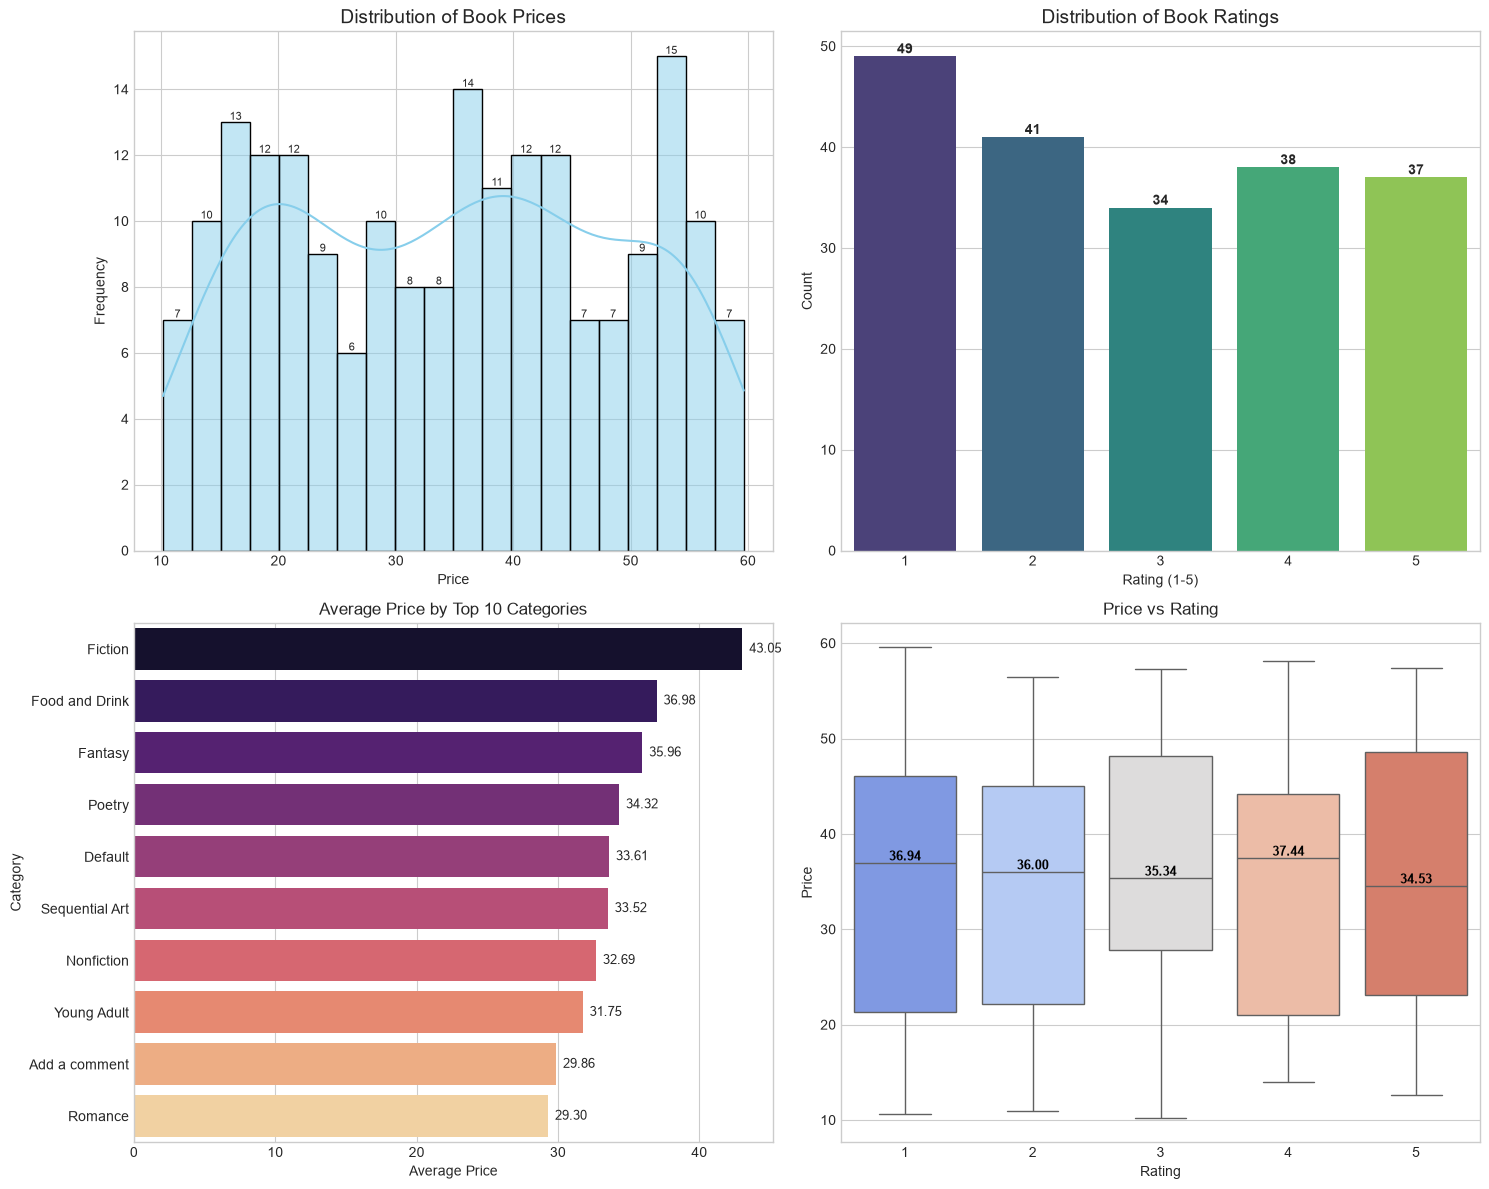


Generated visualizations.png


In [15]:

from wordcloud import WordCloud
import os
import warnings 
warnings.filterwarnings('ignore')


# 1. Summary Statistics and Missing Values
print("--- SUMMARY STATISTICS ---")
print(df[['price', 'rating_int', 'stock_count', 'description_word_count', 'value_score']].describe().round(2).to_markdown())

print("\n--- MISSING VALUES ---")
print(df.isnull().sum().to_markdown())

# Category patterns (Top 5 categories by count)
print("\n--- TOP CATEGORIES BY COUNT ---")
print(df['category'].value_counts().head(5).to_markdown())

print("\n--- AVERAGE RATING BY TOP CATEGORIES ---")
top_cats = df['category'].value_counts().head(5).index
print(df[df['category'].isin(top_cats)].groupby('category')['rating_int'].mean().round(2).to_markdown())

# Visualization setup
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(15, 12))

# Plot 1: Price Distribution
plt.subplot(2, 2, 1)
ax1 = sns.histplot(df['price'], bins=20, kde=True, color='skyblue')

plt.title('Distribution of Book Prices', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Frequency')

# Display frequency on each bar
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height)}',
                     (p.get_x() + p.get_width()/2, height),
                     ha='center',
                     va='bottom',
                     fontsize=8)

plt.subplot(2, 2, 2)
ax2 = sns.countplot(x='rating_int', data=df, palette='viridis')

plt.title('Distribution of Book Ratings', fontsize=14)
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')

# Display count on bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center',
                 va='bottom',
                 fontsize=10,
                 fontweight='bold')

plt.subplot(2, 2, 3)

top_10_categories = df['category'].value_counts().nlargest(10).index
avg_price_cat = (
    df[df['category'].isin(top_10_categories)]
      .groupby('category')['price']
      .mean()
      .sort_values(ascending=False)
)

ax3 = sns.barplot(
    x=avg_price_cat.values,
    y=avg_price_cat.index,
    palette='magma'
)

plt.title('Average Price by Top 10 Categories')
plt.xlabel('Average Price')
plt.ylabel('Category')

# Display average price
for p in ax3.patches:
    ax3.annotate(f'{p.get_width():.2f}',
                 (p.get_width(), p.get_y() + p.get_height()/2),
                 xytext=(5,0),
                 textcoords='offset points',
                 va='center',
                 fontsize=9)

# Plot 4: Relationship - Price vs Rating
plt.subplot(2, 2, 4)
ax4 = sns.boxplot(
    x='rating_int',
    y='price',
    data=df,
    palette='coolwarm'
)

plt.title('Price vs Rating')
plt.xlabel('Rating')
plt.ylabel('Price')

# Median prices
medians = df.groupby('rating_int')['price'].median()

for i, median in enumerate(medians):
    ax4.text(i, median,
             f'{median:.2f}',
             ha='center',
             va='bottom',
             fontsize=9,
             fontweight='bold',
             color='black')

plt.tight_layout()
plt.show()
plt.savefig('visualizations.png')
print("\nGenerated visualizations.png")
plt.close()


Generated wordcloud.png


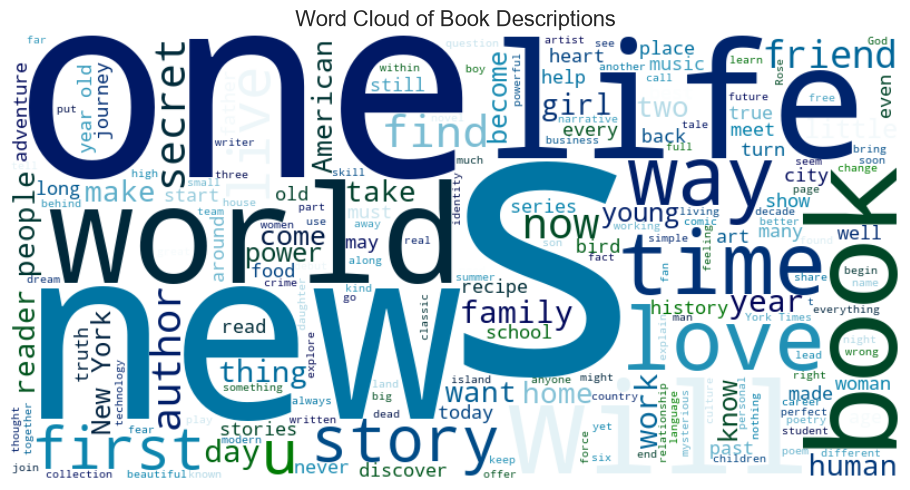

In [17]:
#Word Cloud
text = " ".join(df['description'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='ocean').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Book Descriptions', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud.png')
print("Generated wordcloud.png")
plt.show()
plt.close()

<h2>Summary and Statistics</h2>

Price Range: Books range from £10.16 to £59.64, with an average price of £34.80. The distribution is relatively wide, meaning the store has a healthy mix of budget and premium books.

Average Book rating: 2.86 out of 5

Stock Count (Inventory): The stock pattern is unusually tight. Most books have between 15 and 22 copies available. This suggests the scrape caught a fairly uniform restocking cycle rather than drastically different inventory levels.

Missing Values: The dataset is highly complete. There is only one missing value in the entire dataset, which is a single blank description. There are no unusual outliers in price or stock (e.g., negative prices or corrupted stock counts).

<h2>Insights and Interpretation</h2>

<b>No Correlation Between Price and Quality:</b>The data definitively shows that a higher price does not indicate a better book. The Pearson correlation coefficient between price and rating is exceptionally low. The average price of a 1-star book (£34.58) is virtually identical to the average price of a 5-star book (£34.82).

<b>Representation is Skewed Toward General Fiction:</b> The most highly represented categories in this sample are "Default" (31 books), "Sequential Art" (23 books), and "Nonfiction" (20 books). The "Default" category suggests that many items on the site lack proper metadata or categorization tags.

<b>Representation is Skewed Toward General Fiction:</b> While Fiction and Art populate the site the most, highly specialized genres are strictly the most expensive. The highest mean prices belong to single-instance categories like Women's Fiction (£57.36), Christian (£54.00), and Politics (£51.33), along with Science (£50.16 across two books).

<b>Best Value Resides in Business and Fantasy:</b> When measuring the value_score (Rating to Price ratio), the best bargain in the dataset is The Third Wave: An Entrepreneur's Vision of the Future (Business category), boasting a flawless 5-star rating at just £12.61. This is closely followed by Princess Between Worlds (Fantasy) at £13.34.

<b>Inventory is Heavily Standardized:</b> The site does not simulate realistic retail scarcity. The stock counts range very tightly between 15 and 22 copies for every single book, indicating a uniform baseline restock logic across the backend database.

<b>Standardized Description Lengths:</b> The vast majority of descriptions sit comfortably between 150 and 300 words, forming a distinct cluster on the scatter plot. Authors and publishers tend to aim for this "sweet spot" to maintain reader engagement, regardless of how expensive or critically acclaimed the book is.

<h2>Limitations of the Dataset and Analysis</h2>
several severe limitations must be acknowledged:

<b>Small Sample Size Restriction:</b> Because the scraper was restricted to exactly 5 pages, we are only analyzing a small fraction (approx 100-200 entries) of a site that contains thousands of books. This completely breaks the statistical significance of any category-based pricing, as genres like "Politics" or "Women's Fiction" only contained a single book in this sample.

<b>Static Data </b>: The scrape represents a single, frozen moment in time. We do not have data on historical pricing, whether books go on sale or don't get sales.

<b>Absence of Real Reviews:</b> books.toscrape.com is a sandbox testing environment, not a real store. Because it does not contain genuine written customer reviews, we had to substitute "Description Text" for our text analysis/word cloud. The ratings are fundamentally mocked data, meaning any correlation we find between ratings and prices is an artifact of the site's dummy database, not real-world consumer behavior.